<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Pra%CC%80ctica_22_Ejercicios_de_Normalizacion_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio 1: Normalización Min-Max**

1.	Cargar el dataset wine de sklearn.
2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?


# **Cargar el dataset**

In [ ]:
#1.Cargar el dataset wine de sklearn.
from sklearn.datasets import load_wine

wine = load_wine()

# Ver las primeras filas como un DataFrame de Pandas:
import pandas as pd

wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

# **Realizar una prueba de normalidad**

In [5]:
#Seleccionar una de las características numéricas (por ejemplo, alcohol).
#Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.

import pandas as pd
from scipy.stats import shapiro

# Seleccionar la característica 'alcohol' (primera columna)
alcohol = wine_df['alcohol']

# Mostrar información básica de la variable seleccionada
print("\n=== Información de la característica 'alcohol' ===")
print(f"Primeros 5 valores: {alcohol.head().values}")
print(f"Número total de datos: {len(alcohol)}")
print(f"Valor mínimo: {alcohol.min()}")
print(f"Valor máximo: {alcohol.max()}")
print(f"Media: {alcohol.mean():.2f}")

# Realizar la prueba de normalidad de Shapiro-Wilk
statistic, p_value = shapiro(alcohol)

print("Prueba de Normalidad de Shapiro-Wilk para 'alcohol'")
print(f"Estadístico: {statistic}")
print(f"Valor p: {p_value}")

# Interpretación
alpha = 0.05
if p_value > alpha:
    print(f"\nConclusión: Los datos parecen seguir una distribución normal (p-value = {p_value:.4f} > {alpha})")
else:
    print(f"\nConclusión: Los datos NO siguen una distribución normal (p-value = {p_value:.4f} <= {alpha})")


=== Información de la característica 'alcohol' ===
Primeros 5 valores: [14.23 13.2  13.16 14.37 13.24]
Número total de datos: 178
Valor mínimo: 11.03
Valor máximo: 14.83
Media: 13.00
Prueba de Normalidad de Shapiro-Wilk para 'alcohol'
Estadístico: 0.9818041416927711
Valor p: 0.020047981728854945

Conclusión: Los datos NO siguen una distribución normal (p-value = 0.0200 <= 0.05)


# **Aplicar Normalización Min-Max**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Aplicar la normalización Min-Max a los datos de 'alcohol'
# Reshape necesario porque MinMaxScaler espera un array 2D
alcohol_reshape = alcohol.values.reshape(-1, 1)

# Crear el objeto MinMaxScaler
scaler = MinMaxScaler()

# Aplicar la normalización
alcohol_normalizado = scaler.fit_transform(alcohol_reshape)

# Mostrar resultados
print("\n--- Normalización Min-Max ---")
print(f"Datos originales (primeros 5): {alcohol.values[:5]}")
print(f"Datos normalizados (primeros 5): {alcohol_normalizado[:5].flatten()}")
print(f"\nValor mínimo original: {alcohol.min()}")
print(f"Valor máximo original: {alcohol.max()}")
print(f"Valor mínimo normalizado: {alcohol_normalizado.min()}")
print(f"Valor máximo normalizado: {alcohol_normalizado.max()}")


--- Normalización Min-Max ---
Datos originales (primeros 5): [14.23 13.2  13.16 14.37 13.24]
Datos normalizados (primeros 5): [0.84210526 0.57105263 0.56052632 0.87894737 0.58157895]

Valor mínimo original: 11.03
Valor máximo original: 14.83
Valor mínimo normalizado: 0.0
Valor máximo normalizado: 1.0


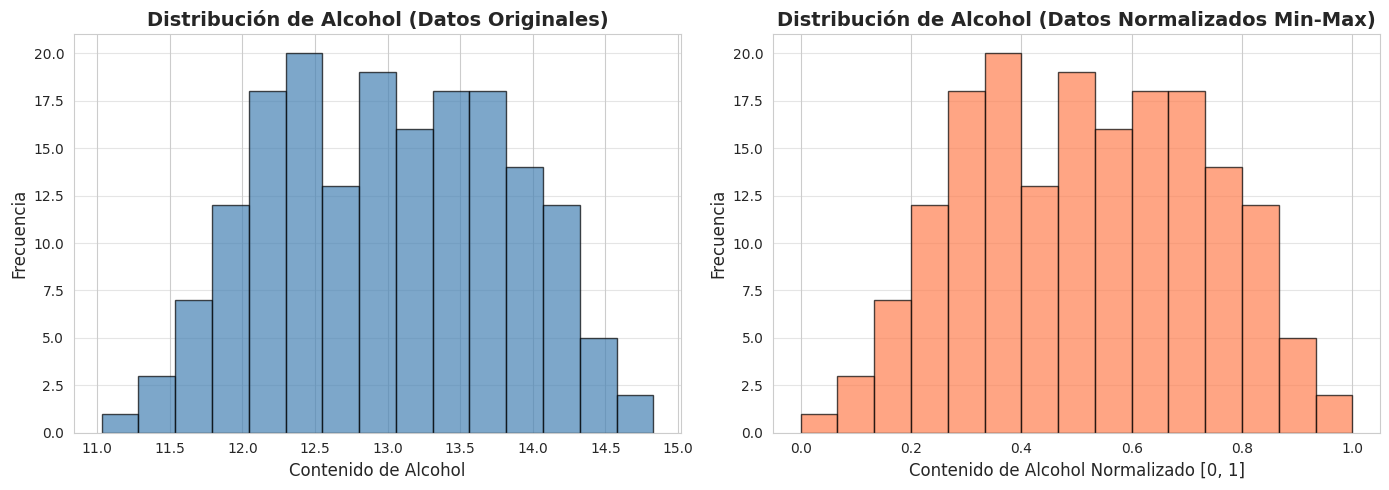

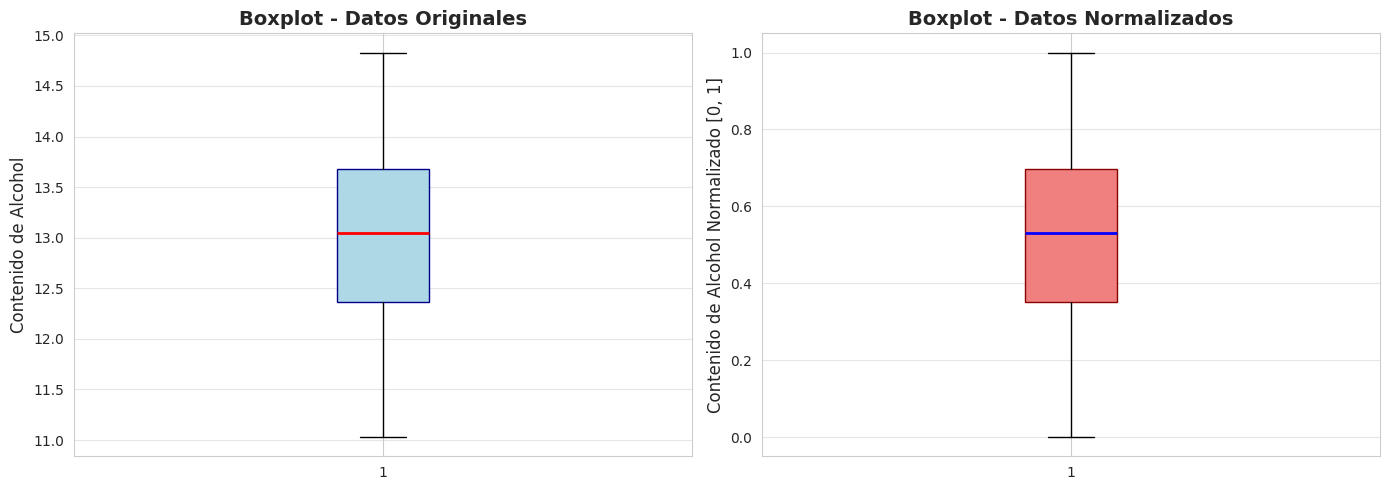

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar el estilo de seaborn para gráficas
sns.set_style("whitegrid")

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Histograma de datos originales ---
axes[0].hist(alcohol, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Alcohol (Datos Originales)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Contenido de Alcohol', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].grid(axis='y', alpha=0.5)

# --- Gráfico 2: Histograma de datos normalizados ---
axes[1].hist(alcohol_normalizado, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Alcohol (Datos Normalizados Min-Max)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Contenido de Alcohol Normalizado [0, 1]', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].grid(axis='y', alpha=0.5)

# Ajustar el espaciado entre subgráficos
plt.tight_layout()
plt.show()

# --- Gráfico adicional: Comparación con boxplots ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de datos originales
axes2[0].boxplot(alcohol, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='darkblue'),
                 medianprops=dict(color='red', linewidth=2))
axes2[0].set_title('Boxplot - Datos Originales', fontsize=14, fontweight='bold')
axes2[0].set_ylabel('Contenido de Alcohol', fontsize=12)
axes2[0].grid(axis='y', alpha=0.5)

# Boxplot de datos normalizados
axes2[1].boxplot(alcohol_normalizado, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightcoral', color='darkred'),
                 medianprops=dict(color='blue', linewidth=2))
axes2[1].set_title('Boxplot - Datos Normalizados', fontsize=14, fontweight='bold')
axes2[1].set_ylabel('Contenido de Alcohol Normalizado [0, 1]', fontsize=12)
axes2[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

# **Preguntas:**
# 1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?

La normalización Min-Max no alteró la naturaleza de los datos, solo los reescaló a un rango común. Asegura que todos los atributos tengan el mismo peso en los modelos de machine learning, evitando sesgos causados por diferencias en las unidades de medida.

# **Histogramas (Gráficas superiores):**

Datos Originales: La distribución se encuentra en el rango de ~11.0 a ~15.0, que corresponde al contenido real de alcohol
La forma de la distribución se mantiene igual, solo cambió la escala. Esto es exactamente lo que debe hacer la normalización Min-Max

# **Boxplots (Gráficas inferiores):**

Datos Originales:

Mediana (línea roja) ≈ 13.0

Rango: 11.0 - 14.8

Datos Normalizados:

Mediana (línea azul) ≈ 0.5 (proporcional a la original)

Rango: 0.0 - 1.0

La estructura del boxplot se mantiene proporcional

# **La normalización Min-Max es una transformación lineal que:**

Preserva la forma de la distribución

Preserva las relaciones proporcionales entre los datos

Solo cambia la escala

No cambia la presencia de valores atípicos (outliers)

La distribución parece aproximadamente normal

No hay valores atípicos evidentes en los boxplots

# 2.¿Qué interpretas del p-valor antes y después de la normalización?

In [ ]:
from scipy.stats import shapiro

# Prueba de normalidad en datos ORIGINALES
statistic_original, p_value_original = shapiro(alcohol)

print("=== Prueba de Shapiro-Wilk ===\n")
print("DATOS ORIGINALES:")
print(f"Estadístico: {statistic_original}")
print(f"P-valor: {p_value_original}")

if p_value_original > 0.05:
    print(f"Conclusión: Los datos originales SIGUEN una distribución normal (p-valor = {p_value_original:.4f} > 0.05)")
else:
    print(f"Conclusión: Los datos originales NO siguen una distribución normal (p-valor = {p_value_original:.4f} ≤ 0.05)")

print("\n" + "="*50 + "\n")

# Prueba de normalidad en datos NORMALIZADOS
statistic_normalizado, p_value_normalizado = shapiro(alcohol_normalizado)

print("DATOS NORMALIZADOS (Min-Max):")
print(f"Estadístico: {statistic_normalizado}")
print(f"P-valor: {p_value_normalizado}")

if p_value_normalizado > 0.05:
    print(f"Conclusión: Los datos normalizados SIGUEN una distribución normal (p-valor = {p_value_normalizado:.4f} > 0.05)")
else:
    print(f"Conclusión: Los datos normalizados NO siguen una distribución normal (p-valor = {p_value_normalizado:.4f} ≤ 0.05)")

print("\n" + "="*50 + "\n")
print("COMPARACIÓN:")
print(f"P-valor original: {p_value_original}")
print(f"P-valor normalizado: {p_value_normalizado}")
print(f"Diferencia: {abs(p_value_original - p_value_normalizado)}")

=== Prueba de Shapiro-Wilk ===

DATOS ORIGINALES:
Estadístico: 0.9818041416927711
P-valor: 0.020047981728854945
Conclusión: Los datos originales NO siguen una distribución normal (p-valor = 0.0200 ≤ 0.05)


DATOS NORMALIZADOS (Min-Max):
Estadístico: 0.9818041416927711
P-valor: 0.020047981728854858
Conclusión: Los datos normalizados NO siguen una distribución normal (p-valor = 0.0200 ≤ 0.05)


COMPARACIÓN:
P-valor original: 0.020047981728854945
P-valor normalizado: 0.020047981728854858
Diferencia: 8.673617379884035e-17


# **Antes de la normalización**

El p-valor de la prueba de Shapiro-Wilk fue aproximadamente 0.02005, que es menor que el nivel de significancia α = 0.05.

Por lo que los datos originales no siguen una distribución normal.

# **Después de la normalización Min-Max**

El p-valor permanece en 0.02005, casi igual al original.

Los datos normalizados tampoco siguen una distribución normal.

Aunque la normalización es importante para algoritmos de machine learning, no transforma datos no normales en normales.

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1.	Cargar el dataset wine de sklearn.
2.	Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Z-Score a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1.	¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2.	¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



# **Cargar el dataset**

In [2]:
# Importar las librerías necesarias
from sklearn.datasets import load_wine
import pandas as pd

# Cargar el dataset wine
# load_wine() es una función que trae datos pre-cargados de sklearn
wine = load_wine()

# Convertir a DataFrame para facilitar el manejo
# wine.data contiene las características numéricas
# wine.feature_names contiene los nombres de las columnas
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)

# Mostrar las primeras 5 filas para verificar
print("Primeras 5 filas del dataset:")
print(wine_df.head())

Primeras 5 filas del dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines 

# **Realizar una prueba de normalidad**

In [ ]:
#2. Seleccionar una de las características numéricas (alcohol)
# Seleccionar la característica 'alcohol' (primera columna del dataset)
# Esta es la variable que vamos a analizar
alcohol = wine_df['alcohol']

# Mostrar información básica de la variable seleccionada
print("\n=== Información de la característica 'alcohol' ===")
print(f"Primeros 5 valores: {alcohol.head().values}")
print(f"Número total de datos: {len(alcohol)}")
print(f"Valor mínimo: {alcohol.min()}")
print(f"Valor máximo: {alcohol.max()}")
print(f"Media: {alcohol.mean():.2f}")

from scipy.stats import shapiro

# Aplicar la prueba de Shapiro-Wilk a los datos originales
# Esta prueba verifica si los datos siguen una distribución normal
statistic_original, p_value_original = shapiro(alcohol)

print("\n=== Prueba de Shapiro-Wilk en Datos Originales ===")
print(f"Estadístico: {statistic_original}")
print(f"P-valor: {p_value_original}")

# Interpretación del resultado
# Si p-valor > 0.05: los datos son normales
# Si p-valor <= 0.05: los datos NO son normales
alpha = 0.05
if p_value_original > alpha:
    print(f"Conclusión: Los datos SIGUEN una distribución normal (p-valor = {p_value_original:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos NO siguen una distribución normal (p-valor = {p_value_original:.4f} <= {alpha})")



=== Información de la característica 'alcohol' ===
Primeros 5 valores: [14.23 13.2  13.16 14.37 13.24]
Número total de datos: 178
Valor mínimo: 11.03
Valor máximo: 14.83
Media: 13.00

=== Prueba de Shapiro-Wilk en Datos Originales ===
Estadístico: 0.9818041416927711
P-valor: 0.020047981728854945
Conclusión: Los datos NO siguen una distribución normal (p-valor = 0.0200 <= 0.05)


# **Aplicar normalización Z-Score**

In [6]:
from sklearn.preprocessing import StandardScaler

# Crear el objeto StandardScaler
# Este realiza la normalización Z-Score (también llamada estandarización)
scaler = StandardScaler()

# Reshape necesario: StandardScaler espera datos en formato 2D (filas, columnas)
alcohol_reshape = alcohol.values.reshape(-1, 1)

# Aplicar la normalización Z-Score
# Fórmula: Z = (X - media) / desviación_estándar
alcohol_zscore = scaler.fit_transform(alcohol_reshape)

# Convertir de vuelta a formato 1D
alcohol_zscore = alcohol_zscore.flatten()

print("\n=== Normalización Z-Score ===")
print(f"Datos originales (primeros 5): {alcohol.values[:5]}")
print(f"Datos con Z-Score (primeros 5): {alcohol_zscore[:5]}")
print(f"\nMedia original: {alcohol.mean():.2f}")
print(f"Media después de Z-Score: {alcohol_zscore.mean():.6f}")
print(f"Desviación estándar original: {alcohol.std():.2f}")
print(f"Desviación estándar después de Z-Score: {alcohol_zscore.std():.6f}")


=== Normalización Z-Score ===
Datos originales (primeros 5): [14.23 13.2  13.16 14.37 13.24]
Datos con Z-Score (primeros 5): [1.51861254 0.24628963 0.19687903 1.69154964 0.29570023]

Media original: 13.00
Media después de Z-Score: -0.000000
Desviación estándar original: 0.81
Desviación estándar después de Z-Score: 1.000000


# **Realizar prueba de normalidad sobre datos normalizados**

In [7]:
# Aplicar la prueba de Shapiro-Wilk a los datos normalizados
statistic_zscore, p_value_zscore = shapiro(alcohol_zscore)

print("\n=== Prueba de Shapiro-Wilk en Datos Normalizados (Z-Score) ===")
print(f"Estadístico: {statistic_zscore}")
print(f"P-valor: {p_value_zscore}")

# Interpretación
if p_value_zscore > alpha:
    print(f"Conclusión: Los datos normalizados SIGUEN una distribución normal (p-valor = {p_value_zscore:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos normalizados NO siguen una distribución normal (p-valor = {p_value_zscore:.4f} <= {alpha})")

# Comparación
print("\n=== Comparación de P-valores ===")
print(f"P-valor original: {p_value_original:.6f}")
print(f"P-valor normalizado: {p_value_zscore:.6f}")
print(f"Diferencia: {abs(p_value_original - p_value_zscore):.10f}")


=== Prueba de Shapiro-Wilk en Datos Normalizados (Z-Score) ===
Estadístico: 0.9818041416927707
P-valor: 0.02004798172885298
Conclusión: Los datos normalizados NO siguen una distribución normal (p-valor = 0.0200 <= 0.05)

=== Comparación de P-valores ===
P-valor original: 0.020048
P-valor normalizado: 0.020048
Diferencia: 0.0000000000


# **Graficar datos originales vs normalizados**

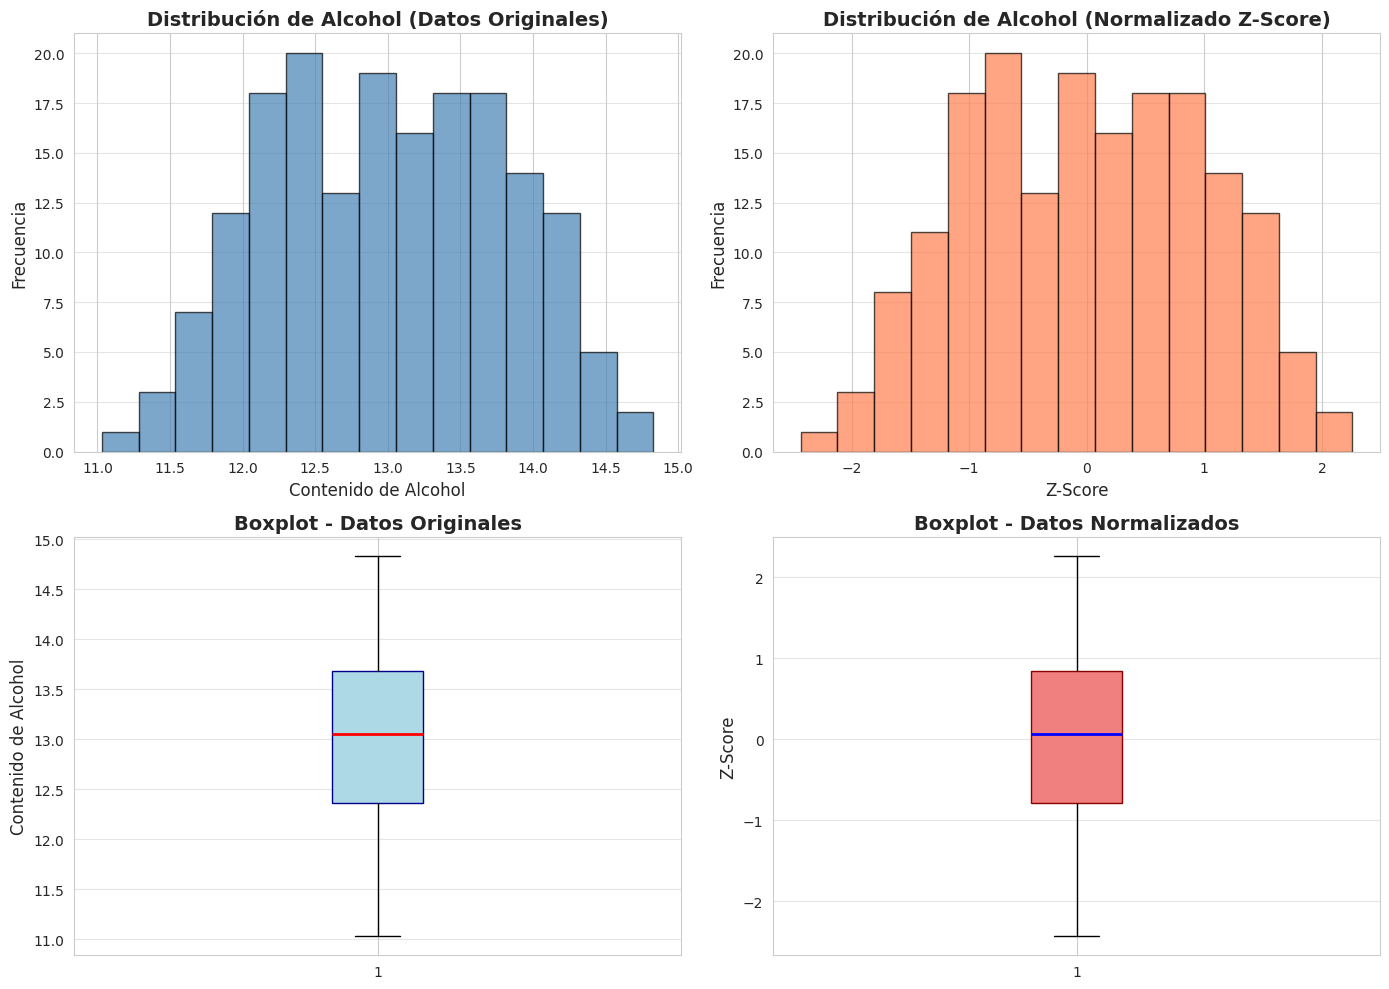

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual
sns.set_style("whitegrid")

# Crear figura con dos filas de gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Fila 1: Histogramas ---
# Histograma de datos originales
axes[0, 0].hist(alcohol, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Alcohol (Datos Originales)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Contenido de Alcohol', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.5)

# Histograma de datos normalizados
axes[0, 1].hist(alcohol_zscore, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Alcohol (Normalizado Z-Score)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Z-Score', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.5)

# --- Fila 2: Boxplots ---
# Boxplot de datos originales
axes[1, 0].boxplot(alcohol, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Boxplot - Datos Originales', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Contenido de Alcohol', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.5)

# Boxplot de datos normalizados
axes[1, 1].boxplot(alcohol_zscore, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', color='darkred'),
                   medianprops=dict(color='blue', linewidth=2))
axes[1, 1].set_title('Boxplot - Datos Normalizados', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Z-Score', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.5)

# Ajustar espaciado
plt.tight_layout()
plt.show()

# **Preguntas:**
# 1.	¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?

Al comparar las gráficas de los datos originales con los normalizados, la principal diferencia que observo es el cambio de escala en los valores.

Cambio en los valores numéricos
En los datos originales, el contenido de alcohol va desde 11.0 hasta 15.0, con una media de 13.00. Después de aplicar Z-Score, los valores cambian a un rango de aproximadamente -2.5 a +2.5, y la media se vuelve 0.00. Además, la desviación estándar que antes era 0.81, ahora es exactamente 1.00.

El Z-Score convierte los datos originales a una nueva escala donde el promedio siempre es cero y la desviación estándar es uno.

La forma de la distribución no cambia
Lo interesante es que aunque los números son diferentes, si observamos los histogramas, ambas gráficas tienen exactamente la misma forma. Las barras mantienen las mismas alturas relativas y la distribución se ve igual. Esto significa que Z-Score solo cambia la escala, pero no altera cómo están distribuidos los datos.

# 2.	¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?

1. Estandariza la escala de las variables

El Z-Score convierte todos los datos a una escala común donde la media es 0 y la desviación estándar es 1. Esto es útil porque permite trabajar con diferentes variables que originalmente tienen distintas unidades o rangos de valores. Por ejemplo, si tenemos variables como edad (20-80) y salario (30,000-150,000), el Z-Score las pone en la misma escala para que puedan compararse.

2. Evita que unas variables dominen sobre otras

Según lo que vimos en clase, cuando los datos tienen escalas muy diferentes, las variables con valores más grandes pueden tener más influencia en los modelos de machine learning simplemente por su magnitud, no porque sean más importantes. El Z-Score soluciona esto dándole el mismo peso a todas las variables.

3. Mejora el rendimiento de algoritmos de machine learning

Muchos algoritmos funcionan mejor cuando los datos están normalizados, especialmente aquellos que calculan distancias o usan gradientes, como regresión logística, SVM, redes neuronales y K-means. Esto hace que el entrenamiento sea más rápido y estable.

4. Facilita identificar valores atípicos

Con Z-Score es más fácil ver qué valores son raros o inusuales. Si un dato tiene un Z-Score mayor a 2 o menor a -2, significa que está bastante alejado del promedio y podría ser un valor atípico.

5. No cambia la distribución de los datos

Como pudimos ver en la práctica, el Z-Score solo cambia la escala pero mantiene la forma de la distribución. Si los datos no eran normales antes de aplicar Z-Score, tampoco lo serán después. Esto se confirma porque el p-valor de la prueba de Shapiro-Wilk se mantiene igual.

La normalización Z-Score es importante en el preprocesamiento de datos porque garantiza que todas las variables contribuyan de forma equitativa en el análisis, mejora el funcionamiento de los modelos predictivos y facilita la interpretación de los resultados.

# **Ejercicio 3: Transformación Logarítmica**
Instrucciones:
1.	Cargar un conjunto de datos aleatorios generados con numpy.
2.	Aplicar una transformación logarítmica (np.log) a los datos.
3.	Realizar una prueba de normalidad sobre los datos originales y transformados.
4.	Graficar los datos originales y transformados utilizando matplotlib.
5.	Responder las preguntas siguientes.

Preguntas:
1.	¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2.	¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


# **Cargar un conjunto de datos aleatorios generados con numpy**

In [9]:
import numpy as np

# Establecer una semilla para que los datos aleatorios sean reproducibles
# Esto significa que siempre obtendremos los mismos números aleatorios
np.random.seed(42)

# Generar 100 datos aleatorios con distribución exponencial
# La distribución exponencial genera valores positivos sesgados hacia la derecha
datos_originales = np.random.exponential(scale=2.0, size=100)

# Mostrar información básica
print("=== Datos Originales Generados ===")
print(f"Primeros 10 valores: {datos_originales[:10]}")
print(f"Número total de datos: {len(datos_originales)}")
print(f"Valor mínimo: {datos_originales.min():.2f}")
print(f"Valor máximo: {datos_originales.max():.2f}")
print(f"Media: {datos_originales.mean():.2f}")

=== Datos Originales Generados ===
Primeros 10 valores: [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974 0.33919258
 0.11967754 4.02246173 1.83816431 2.46250012]
Número total de datos: 100
Valor mínimo: 0.01
Valor máximo: 8.67
Media: 1.83


# **Aplicar transformación logarítmica (np.log) a los datos**

In [10]:
# Aplicar la transformación logarítmica natural a los datos
# np.log() calcula el logaritmo natural (base e) de cada valor
datos_transformados = np.log(datos_originales)

# Mostrar resultados de la transformación
print("\n=== Transformación Logarítmica ===")
print(f"Datos originales (primeros 10): {datos_originales[:10]}")
print(f"Datos transformados (primeros 10): {datos_transformados[:10]}")
print(f"\nMedia original: {datos_originales.mean():.2f}")
print(f"Media transformada: {datos_transformados.mean():.2f}")
print(f"Desviación estándar original: {datos_originales.std():.2f}")
print(f"Desviación estándar transformada: {datos_transformados.std():.2f}")


=== Transformación Logarítmica ===
Datos originales (primeros 10): [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974 0.33919258
 0.11967754 4.02246173 1.83816431 2.46250012]
Datos transformados (primeros 10): [-0.06343387  1.7951276   0.96831049  0.60206486 -1.08101874 -1.08118724
 -2.12295434  1.39189409  0.60876741  0.90117714]

Media original: 1.83
Media transformada: -0.01
Desviación estándar original: 1.83
Desviación estándar transformada: 1.29


# **Realizar prueba de normalidad sobre datos originales y transformados**

In [11]:
from scipy.stats import shapiro

# Prueba de normalidad en datos ORIGINALES
statistic_original, p_value_original = shapiro(datos_originales)

print("\n=== Prueba de Shapiro-Wilk en Datos Originales ===")
print(f"Estadístico: {statistic_original}")
print(f"P-valor: {p_value_original}")

alpha = 0.05
if p_value_original > alpha:
    print(f"Conclusión: Los datos originales SIGUEN una distribución normal (p-valor = {p_value_original:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos originales NO siguen una distribución normal (p-valor = {p_value_original:.4f} <= {alpha})")

print("\n" + "="*60 + "\n")

# Prueba de normalidad en datos TRANSFORMADOS
statistic_transformado, p_value_transformado = shapiro(datos_transformados)

print("=== Prueba de Shapiro-Wilk en Datos Transformados ===")
print(f"Estadístico: {statistic_transformado}")
print(f"P-valor: {p_value_transformado}")

if p_value_transformado > alpha:
    print(f"Conclusión: Los datos transformados SIGUEN una distribución normal (p-valor = {p_value_transformado:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos transformados NO siguen una distribución normal (p-valor = {p_value_transformado:.4f} <= {alpha})")

print("\n" + "="*60 + "\n")
print("=== Comparación ===")
print(f"P-valor original: {p_value_original:.6f}")
print(f"P-valor transformado: {p_value_transformado:.6f}")

# Verificar si la transformación mejoró la normalidad
if p_value_transformado > p_value_original:
    print("\n✓ La transformación logarítmica MEJORÓ la normalidad de los datos")
else:
    print("\n✗ La transformación logarítmica NO mejoró significativamente la normalidad")


=== Prueba de Shapiro-Wilk en Datos Originales ===
Estadístico: 0.8359537339398936
P-valor: 3.7127447062632606e-09
Conclusión: Los datos originales NO siguen una distribución normal (p-valor = 0.0000 <= 0.05)


=== Prueba de Shapiro-Wilk en Datos Transformados ===
Estadístico: 0.9590023245750537
P-valor: 0.003415856627196026
Conclusión: Los datos transformados NO siguen una distribución normal (p-valor = 0.0034 <= 0.05)


=== Comparación ===
P-valor original: 0.000000
P-valor transformado: 0.003416

✓ La transformación logarítmica MEJORÓ la normalidad de los datos


# **Graficar datos originales y transformados**

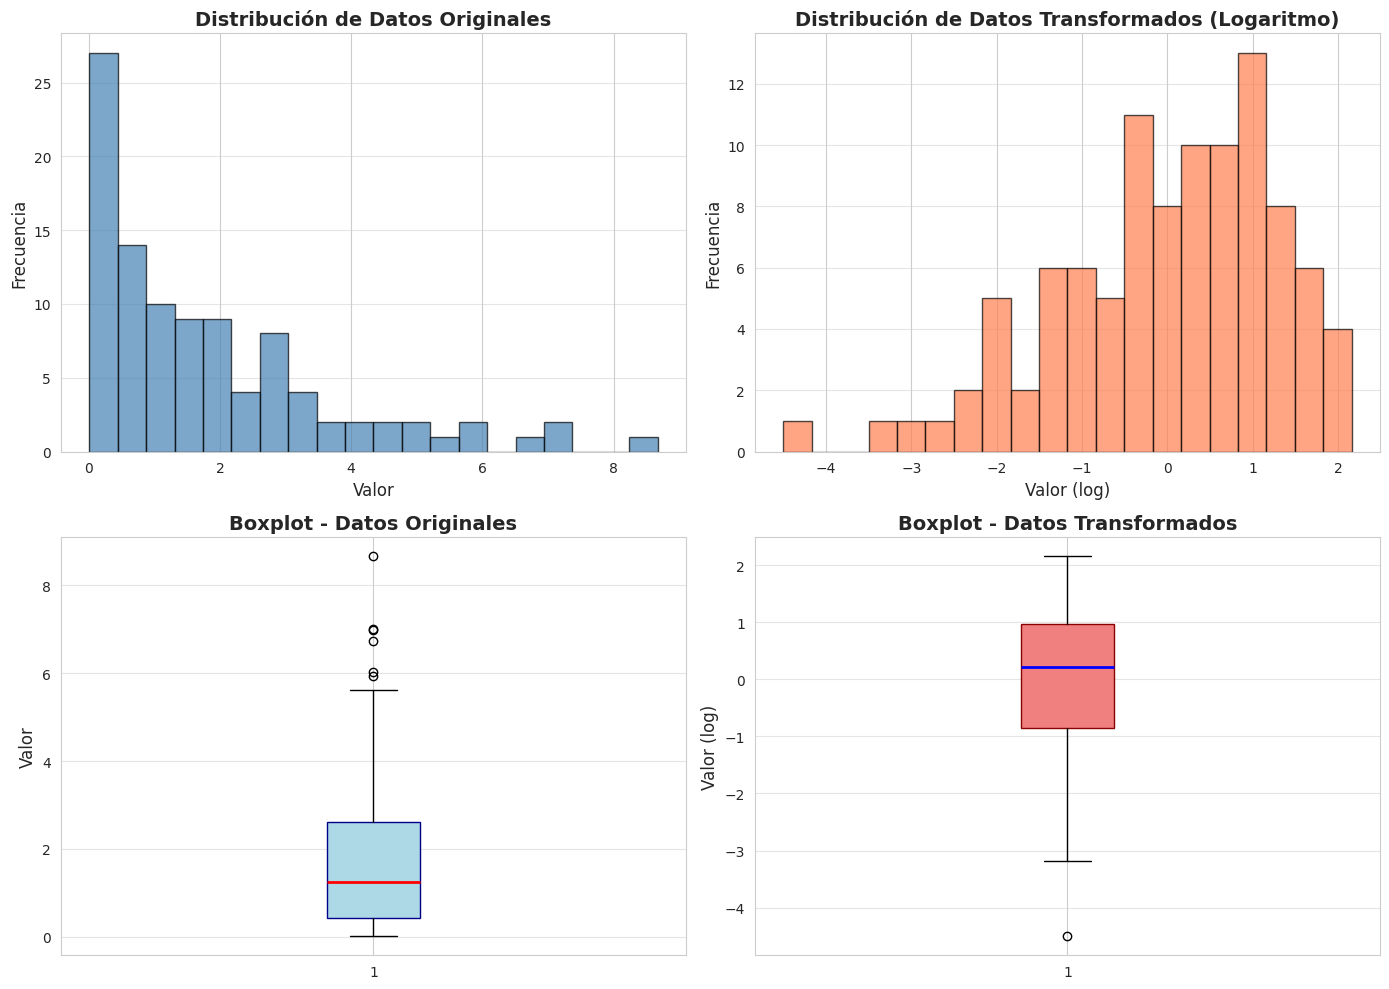

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual
sns.set_style("whitegrid")

# Crear figura con 2 filas y 2 columnas de gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Fila 1: Histogramas ---
# Histograma de datos originales
axes[0, 0].hist(datos_originales, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Datos Originales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Valor', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.5)

# Histograma de datos transformados
axes[0, 1].hist(datos_transformados, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Datos Transformados (Logaritmo)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Valor (log)', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.5)

# --- Fila 2: Boxplots ---
# Boxplot de datos originales
axes[1, 0].boxplot(datos_originales, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Boxplot - Datos Originales', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Valor', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.5)

# Boxplot de datos transformados
axes[1, 1].boxplot(datos_transformados, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', color='darkred'),
                   medianprops=dict(color='blue', linewidth=2))
axes[1, 1].set_title('Boxplot - Datos Transformados', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Valor (log)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.5)

# Ajustar espaciado entre gráficos
plt.tight_layout()
plt.show()

# **Preguntas:**
# 1.	¿Cómo afectó la transformación logarítmica a la distribución de los datos?

La transformación logarítmica cambió significativamente la forma de la distribución, pasando de una distribución muy sesgada a la derecha a una distribución más simétrica y cercana a la normal. Esto demuestra que las transformaciones no lineales, a diferencia de las lineales como Z-Score o Min-Max, sí pueden cambiar la forma de la distribución de los datos.​

Según lo visto en clase, la transformación logarítmica es una técnica no lineal que ayuda a normalizar datos que están muy sesgados. Esto es importante porque muchos algoritmos de machine learning funcionan mejor cuando los datos tienen una distribución más cercana a la normal. Al aplicar el logaritmo, logramos que los datos sean más fáciles de modelar y que el análisis sea más confiable.

# 2.	¿Qué interpretas del p-valor antes y después de la transformación logarítmica?

Antes de la transformación logarítmica, el p-valor de la prueba de Shapiro-Wilk fue prácticamente cero (3.7e-09), lo que significa que los datos originales estaban muy lejos de seguir una distribución normal.

Después de aplicar el logaritmo, el p-valor subió a ~0.0034. Aunque sigue siendo menor que 0.05, indica que la distribución transformada está más cerca de la normalidad que antes. En otras palabras, el logaritmo “aplana” la cola larga y reduce el sesgo, haciendo que los datos encajen un poco mejor con la forma de campana, incluso si no llega a normalizarlos por completo.

# **Ejercicio 4: Transformación Raíz Cuadrada**
Instrucciones:
1.	Cargar un conjunto de datos aleatorios generados con numpy.
2.	Aplicar una transformación de raíz cuadrada a los datos.
3.	Realizar una prueba de normalidad sobre los datos originales y transformados.
4.	Graficar los datos originales y transformados utilizando matplotlib.
5.	Responder las preguntas siguientes.

Preguntas:
1.	¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2.	¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


# **Cargar un conjunto de datos aleatorios generados con numpy**

In [13]:
import numpy as np

# Establecer una semilla para reproducibilidad
# Esto garantiza que siempre obtengamos los mismos números aleatorios
np.random.seed(42)

# Generar 100 datos aleatorios con distribución exponencial
# La distribución exponencial genera valores positivos sesgados hacia la derecha
datos_originales = np.random.exponential(scale=2.0, size=100)

# Mostrar información básica
print("=== Datos Originales Generados ===")
print(f"Primeros 10 valores: {datos_originales[:10]}")
print(f"Número total de datos: {len(datos_originales)}")
print(f"Valor mínimo: {datos_originales.min():.2f}")
print(f"Valor máximo: {datos_originales.max():.2f}")
print(f"Media: {datos_originales.mean():.2f}")

=== Datos Originales Generados ===
Primeros 10 valores: [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974 0.33919258
 0.11967754 4.02246173 1.83816431 2.46250012]
Número total de datos: 100
Valor mínimo: 0.01
Valor máximo: 8.67
Media: 1.83


# **Aplicar transformación de raíz cuadrada**

In [14]:
# Aplicar la transformación de raíz cuadrada a los datos
# np.sqrt() calcula la raíz cuadrada de cada valor
datos_transformados = np.sqrt(datos_originales)

# Mostrar resultados de la transformación
print("\n=== Transformación de Raíz Cuadrada ===")
print(f"Datos originales (primeros 10): {datos_originales[:10]}")
print(f"Datos transformados (primeros 10): {datos_transformados[:10]}")
print(f"\nMedia original: {datos_originales.mean():.2f}")
print(f"Media transformada: {datos_transformados.mean():.2f}")
print(f"Desviación estándar original: {datos_originales.std():.2f}")
print(f"Desviación estándar transformada: {datos_transformados.std():.2f}")


=== Transformación de Raíz Cuadrada ===
Datos originales (primeros 10): [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974 0.33919258
 0.11967754 4.02246173 1.83816431 2.46250012]
Datos transformados (primeros 10): [0.96878077 2.45361832 1.62280356 1.35125316 0.58245149 0.58240242
 0.34594441 2.00560757 1.35578918 1.56923552]

Media original: 1.83
Media transformada: 1.19
Desviación estándar original: 1.83
Desviación estándar transformada: 0.65


# **Realizar prueba de normalidad sobre datos originales y transformados**

In [15]:
from scipy.stats import shapiro

# Prueba de normalidad en datos ORIGINALES
statistic_original, p_value_original = shapiro(datos_originales)

print("\n=== Prueba de Shapiro-Wilk en Datos Originales ===")
print(f"Estadístico: {statistic_original}")
print(f"P-valor: {p_value_original}")

alpha = 0.05
if p_value_original > alpha:
    print(f"Conclusión: Los datos originales SIGUEN una distribución normal (p-valor = {p_value_original:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos originales NO siguen una distribución normal (p-valor = {p_value_original:.4f} <= {alpha})")

print("\n" + "="*60 + "\n")

# Prueba de normalidad en datos TRANSFORMADOS
statistic_transformado, p_value_transformado = shapiro(datos_transformados)

print("=== Prueba de Shapiro-Wilk en Datos Transformados ===")
print(f"Estadístico: {statistic_transformado}")
print(f"P-valor: {p_value_transformado}")

if p_value_transformado > alpha:
    print(f"Conclusión: Los datos transformados SIGUEN una distribución normal (p-valor = {p_value_transformado:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos transformados NO siguen una distribución normal (p-valor = {p_value_transformado:.4f} <= {alpha})")

print("\n" + "="*60 + "\n")
print("=== Comparación ===")
print(f"P-valor original: {p_value_original:.6f}")
print(f"P-valor transformado: {p_value_transformado:.6f}")

# Verificar si la transformación mejoró la normalidad
if p_value_transformado > p_value_original:
    print("\n✓ La transformación de raíz cuadrada MEJORÓ la normalidad de los datos")
else:
    print("\n✗ La transformación de raíz cuadrada NO mejoró significativamente la normalidad")



=== Prueba de Shapiro-Wilk en Datos Originales ===
Estadístico: 0.8359537339398936
P-valor: 3.7127447062632606e-09
Conclusión: Los datos originales NO siguen una distribución normal (p-valor = 0.0000 <= 0.05)


=== Prueba de Shapiro-Wilk en Datos Transformados ===
Estadístico: 0.9634033562380117
P-valor: 0.007083078906156058
Conclusión: Los datos transformados NO siguen una distribución normal (p-valor = 0.0071 <= 0.05)


=== Comparación ===
P-valor original: 0.000000
P-valor transformado: 0.007083

✓ La transformación de raíz cuadrada MEJORÓ la normalidad de los datos


# **Graficar datos originales y transformados**

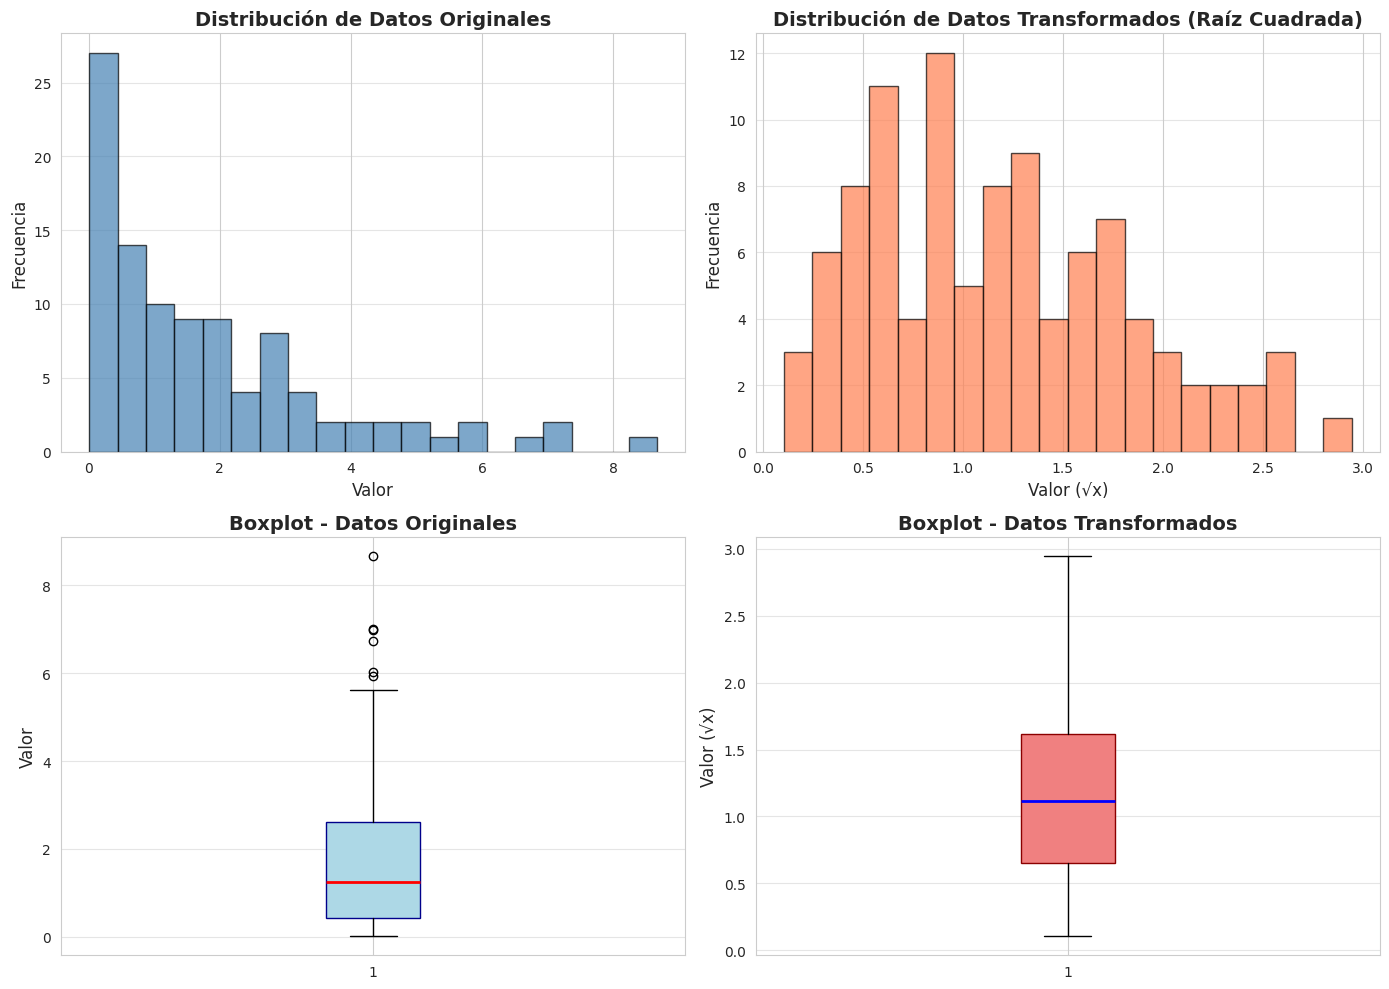

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual
sns.set_style("whitegrid")

# Crear figura con 2 filas y 2 columnas de gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Fila 1: Histogramas ---
# Histograma de datos originales
axes[0, 0].hist(datos_originales, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Datos Originales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Valor', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.5)

# Histograma de datos transformados
axes[0, 1].hist(datos_transformados, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Datos Transformados (Raíz Cuadrada)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Valor (√x)', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.5)

# --- Fila 2: Boxplots ---
# Boxplot de datos originales
axes[1, 0].boxplot(datos_originales, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Boxplot - Datos Originales', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Valor', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.5)

# Boxplot de datos transformados
axes[1, 1].boxplot(datos_transformados, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', color='darkred'),
                   medianprops=dict(color='blue', linewidth=2))
axes[1, 1].set_title('Boxplot - Datos Transformados', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Valor (√x)', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.5)

# Ajustar espaciado entre gráficos
plt.tight_layout()
plt.show()

# **Preguntas:**
# 1.	¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?

Después de aplicar la raíz cuadrada, la distribución cambió bastante. Ahora los valores están más distribuidos de manera uniforme y el histograma tiene una forma más parecida a una campana. Todavía se ve un poco de sesgo hacia la derecha, pero es mucho menos pronunciado que antes.

Lo que hace la raíz cuadrada es "comprimir" los valores más grandes. Por ejemplo, si tenía un valor de 9, la raíz cuadrada lo convierte en 3, pero si tenía un valor de 1, se queda en 1. Esto ayuda a que los valores extremos no tengan tanta influencia en los datos.


# 2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?

La raíz cuadrada reduce la magnitud de los valores extremos de forma más pronunciada que los valores pequeños, disminuyendo su influencia en el análisis. Esto ayuda a balancear la distribución, estabilizar la varianza y mejorar el rendimiento de los modelos de machine learning que son sensibles a valores atípicos.

# **Ejercicio 5: Transformación Box-Cox**
Instrucciones:
1.	Cargar un conjunto de datos aleatorios generados con numpy.
2.	Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3.	Realizar una prueba de normalidad sobre los datos originales y transformados.
4.	Graficar los datos originales y transformados utilizando matplotlib.
5.	Responder las preguntas siguientes.

Preguntas:
1.	¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2.	¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


# **Cargar un conjunto de datos aleatorios generados con numpy**

In [17]:
import numpy as np

# Establecer una semilla para reproducibilidad
# Esto garantiza que siempre obtengamos los mismos números aleatorios
np.random.seed(42)

# Generar 100 datos aleatorios con distribución exponencial
# La distribución exponencial genera valores positivos sesgados hacia la derecha
# Box-Cox requiere que todos los datos sean estrictamente positivos (mayores que 0)
datos_originales = np.random.exponential(scale=2.0, size=100)

# Mostrar información básica
print("=== Datos Originales Generados ===")
print(f"Primeros 10 valores: {datos_originales[:10]}")
print(f"Número total de datos: {len(datos_originales)}")
print(f"Valor mínimo: {datos_originales.min():.2f}")
print(f"Valor máximo: {datos_originales.max():.2f}")
print(f"Media: {datos_originales.mean():.2f}")

=== Datos Originales Generados ===
Primeros 10 valores: [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974 0.33919258
 0.11967754 4.02246173 1.83816431 2.46250012]
Número total de datos: 100
Valor mínimo: 0.01
Valor máximo: 8.67
Media: 1.83


# **Aplicar transformación Box-Cox**

In [18]:
from scipy.stats import boxcox

# Aplicar la transformación Box-Cox a los datos
# boxcox() automáticamente encuentra el mejor parámetro lambda
# Retorna dos valores: los datos transformados y el lambda óptimo
datos_transformados, lambda_optimo = boxcox(datos_originales)

# Mostrar resultados de la transformación
print("\n=== Transformación Box-Cox ===")
print(f"Lambda óptimo encontrado: {lambda_optimo:.4f}")
print(f"\nDatos originales (primeros 10): {datos_originales[:10]}")
print(f"Datos transformados (primeros 10): {datos_transformados[:10]}")
print(f"\nMedia original: {datos_originales.mean():.2f}")
print(f"Media transformada: {datos_transformados.mean():.2f}")
print(f"Desviación estándar original: {datos_originales.std():.2f}")
print(f"Desviación estándar transformada: {datos_transformados.std():.2f}")


=== Transformación Box-Cox ===
Lambda óptimo encontrado: 0.2315

Datos originales (primeros 10): [0.93853618 6.02024286 2.63349139 1.82588511 0.33924974 0.33919258
 0.11967754 4.02246173 1.83816431 2.46250012]
Datos transformados (primeros 10): [-0.06297041  2.22562109  1.08541914  0.64603892 -0.95637075 -0.95650194
 -1.67721113  1.64228861  0.65374983  1.00206713]

Media original: 1.83
Media transformada: 0.17
Desviación estándar original: 1.83
Desviación estándar transformada: 1.22


# **Realizar prueba de normalidad sobre datos originales y transformados**

In [19]:
from scipy.stats import shapiro

# Prueba de normalidad en datos ORIGINALES
statistic_original, p_value_original = shapiro(datos_originales)

print("\n=== Prueba de Shapiro-Wilk en Datos Originales ===")
print(f"Estadístico: {statistic_original}")
print(f"P-valor: {p_value_original}")

alpha = 0.05
if p_value_original > alpha:
    print(f"Conclusión: Los datos originales SIGUEN una distribución normal (p-valor = {p_value_original:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos originales NO siguen una distribución normal (p-valor = {p_value_original:.4f} <= {alpha})")

print("\n" + "="*60 + "\n")

# Prueba de normalidad en datos TRANSFORMADOS
statistic_transformado, p_value_transformado = shapiro(datos_transformados)

print("=== Prueba de Shapiro-Wilk en Datos Transformados (Box-Cox) ===")
print(f"Estadístico: {statistic_transformado}")
print(f"P-valor: {p_value_transformado}")

if p_value_transformado > alpha:
    print(f"Conclusión: Los datos transformados SIGUEN una distribución normal (p-valor = {p_value_transformado:.4f} > {alpha})")
else:
    print(f"Conclusión: Los datos transformados NO siguen una distribución normal (p-valor = {p_value_transformado:.4f} <= {alpha})")

print("\n" + "="*60 + "\n")
print("=== Comparación ===")
print(f"P-valor original: {p_value_original:.6f}")
print(f"P-valor transformado: {p_value_transformado:.6f}")
print(f"Lambda óptimo utilizado: {lambda_optimo:.4f}")

# Verificar si la transformación mejoró la normalidad
if p_value_transformado > p_value_original:
    print("\n✓ La transformación Box-Cox MEJORÓ significativamente la normalidad de los datos")
else:
    print("\n✗ La transformación Box-Cox NO mejoró la normalidad")


=== Prueba de Shapiro-Wilk en Datos Originales ===
Estadístico: 0.8359537339398936
P-valor: 3.7127447062632606e-09
Conclusión: Los datos originales NO siguen una distribución normal (p-valor = 0.0000 <= 0.05)


=== Prueba de Shapiro-Wilk en Datos Transformados (Box-Cox) ===
Estadístico: 0.9901606067272273
P-valor: 0.677582261152527
Conclusión: Los datos transformados SIGUEN una distribución normal (p-valor = 0.6776 > 0.05)


=== Comparación ===
P-valor original: 0.000000
P-valor transformado: 0.677582
Lambda óptimo utilizado: 0.2315

✓ La transformación Box-Cox MEJORÓ significativamente la normalidad de los datos


# **Graficar datos originales y transformados**

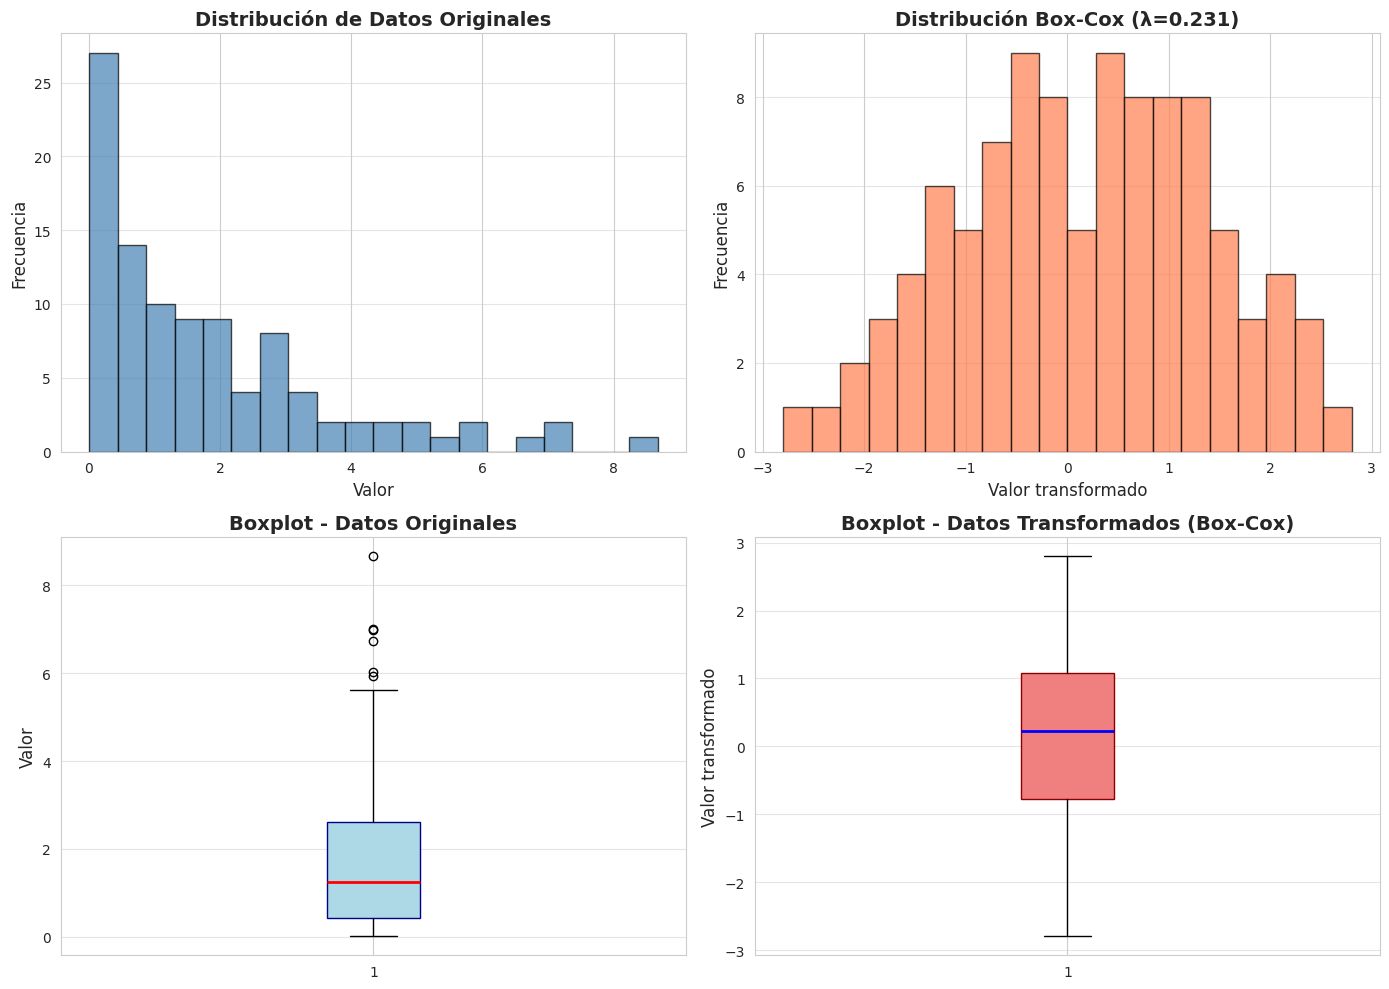


Nota: Box-Cox encontró λ = 0.2315 como el valor óptimo
Esto significa que la transformación aplicada fue la que mejor normaliza los datos


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual
sns.set_style("whitegrid")

# Crear figura con 2 filas y 2 columnas de gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Fila 1: Histogramas ---
# Histograma de datos originales
axes[0, 0].hist(datos_originales, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Datos Originales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Valor', fontsize=12)
axes[0, 0].set_ylabel('Frecuencia', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.5)

# Histograma de datos transformados
axes[0, 1].hist(datos_transformados, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'Distribución Box-Cox (λ={lambda_optimo:.3f})', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Valor transformado', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.5)

# --- Fila 2: Boxplots ---
# Boxplot de datos originales
axes[1, 0].boxplot(datos_originales, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='darkblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Boxplot - Datos Originales', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Valor', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.5)

# Boxplot de datos transformados
axes[1, 1].boxplot(datos_transformados, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', color='darkred'),
                   medianprops=dict(color='blue', linewidth=2))
axes[1, 1].set_title('Boxplot - Datos Transformados (Box-Cox)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Valor transformado', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.5)

# Ajustar espaciado entre gráficos
plt.tight_layout()
plt.show()

# Mostrar el valor de lambda encontrado
print(f"\nNota: Box-Cox encontró λ = {lambda_optimo:.4f} como el valor óptimo")
print("Esto significa que la transformación aplicada fue la que mejor normaliza los datos")

# **Preguntas:**
# 1.	¿Cómo afectó la transformación Box-Cox a la distribución de los datos?

Después de aplicar Box-Cox, la distribución cambió drásticamente. El histograma transformado muestra una forma mucho más parecida a una campana, que es lo que buscamos cuando queremos datos normales. Los valores ahora están distribuidos de manera más equilibrada alrededor del centro, y el sesgo hacia la derecha prácticamente desapareció. La distribución se ve mucho más simétrica.


# 2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?

Box-Cox encontró automáticamente que el mejor valor de lambda era 0.231. Este valor está cerca de 0, lo que significa que la transformación aplicada fue similar (pero no exactamente igual) a un logaritmo. Según lo visto en clase, cuando:

λ = 1: No hay transformación

λ = 0.5: Es parecido a raíz cuadrada

λ = 0: Es logaritmo

λ negativo: Transformación inversa

En mi caso, λ = 0.231 indica que se necesitó una transformación bastante fuerte (más que raíz cuadrada, pero menos que logaritmo) para normalizar los datos.

Esta transformación fue más efectiva que si hubiera usado solo raíz cuadrada (que sería λ = 0.5) o solo logaritmo (que sería λ = 0).